# Práctica 2 — Determinación de tipos de estrellas

Matias Djukic           100504112@alumnos.uc3m.es
José María Duro Agea    100522306@alumnos.uc3m.es

## 1. Carga y preprocesamiento de datos

En este apartado se cargan los datos, se realiza una exploración inicial y se codifican de forma ordinal las variables categóricas (`Color` y `Spectral_Class`), respetando el orden físico subyacente de cada una.

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

SEED = 100504112

np.random.seed(SEED)

### 1.1 Carga del conjunto de datos

In [74]:
df = pd.read_csv("stars_data.csv")
print(f"Dimensiones: {df.shape}")
df.head()

Dimensiones: (240, 6)


,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,Red,M
1,3042,0.000500,0.1542,16.60,Red,M
2,2600,0.000300,0.1020,18.70,Red,M
3,2800,0.000200,0.1600,16.65,Red,M
4,1939,0.000138,0.1030,20.06,Red,M


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    object 
 5   Spectral_Class  240 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 11.4+ KB


In [76]:
df.describe()

,Temperature,L,R,A_M
count,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396
std,9552.425037,179432.244940,517.155763,10.532512
min,1939.000000,0.000080,0.008400,-11.920000
25%,3344.250000,0.000865,0.102750,-6.232500
50%,5776.000000,0.070500,0.762500,8.313000
75%,15055.500000,198050.000000,42.750000,13.697500
max,40000.000000,849420.000000,1948.500000,20.060000


In [77]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print()
print("Valores únicos — Color:")
print(sorted(df["Color"].unique()))
print()
print("Valores únicos — Spectral_Class:")
print(sorted(df["Spectral_Class"].unique()))

Valores nulos por columna:
Temperature       0
L                 0
R                 0
A_M               0
Color             0
Spectral_Class    0
dtype: int64

Valores únicos — Color:
['Blue', 'Blue White', 'Blue white', 'Blue-White', 'Blue-white', 'Orange', 'Orange-Red', 'Pale yellow orange', 'Red', 'White', 'White-Yellow', 'Whitish', 'Yellowish', 'Yellowish White', 'white', 'yellow-white', 'yellowish']

Valores únicos — Spectral_Class:
['A', 'B', 'F', 'G', 'K', 'M', 'O']


### 1.2 Limpieza y Codificación Ordinal de Variables Categóricas

En astronomía, las variables `Color` y `Spectral_Class` no son etiquetas nominales aleatorias, sino que responden a un orden físico estricto basado en la energía y temperatura superficial de la estrella. Por ello, aplicaremos **codificación ordinal** (y no *One-Hot Encoding*, que destruiría la noción de distancia térmica entre categorías).

* **`Spectral_Class`**: La secuencia espectral estándar de mayor a menor temperatura es O → B → A → F → G → K → M.
* **`Color`**: Fluye desde las estrellas más masivas y calientes (azules) hasta las más frías (rojas).

**Procedimiento de resolución de anomalías:**
En lugar de forzar reemplazos textuales a ciegas o permitir que el codificador asigne valores erróneos (`-1`) a colores atípicos por errores tipográficos en el dataset (ej. "whitish"), aplicaremos un enfoque analítico:
1. Aislar las estrellas con colores no estándar.
2. Calcular su perfil térmico real.
3. Mapearlas algorítmicamente a la categoría estándar cuya temperatura media sea más similar.

In [78]:
# ========================================================
# IDENTIFICACIÓN Y AISLAMIENTO DE CATEGORÍAS NO ESTÁNDAR
# ========================================================

# 1. Limpieza básica de formato
df["Color"] = df["Color"].str.strip().str.lower()
df["Spectral_Class"] = df["Spectral_Class"].str.strip().str.upper()

# 2. Orden físico de colores: de más frío (rojo) a más caliente (azul).
# Asignamos índice creciente con la temperatura, igual que ocurre con
# Spectral_Class (O=0 es la más caliente, pero en Color invertimos para
# que ambas variables sean MONÓTONAS CON LA TEMPERATURA en la misma dirección:
# mayor índice = mayor temperatura = mayor energía).
#
# Convención adoptada: 0 = rojo (más frío) → 13 = azul (más caliente)
# Esto hace que Color_enc y Temperature correlacionen positivamente,
# facilitando la interpretación de los loadings del PCA.
color_order = [
    "red", "orange-red", "orange", "yellow", "yellowish",
    "white-yellow", "yellowish white", "pale yellow orange",
    "yellow white", "yellow-white", "white", "blue white",
    "blue-white", "blue"
]

# 3. Agrupamos las estrellas que NO coinciden con nuestras categorías
estrellas_anomalas = df[~df["Color"].isin(color_order)]

print(f"Se han aislado {len(estrellas_anomalas)} estrellas con colores fuera del estándar.")

# Mostramos el grupo para inspección visual
if len(estrellas_anomalas) > 0:
    display(estrellas_anomalas)

Se han aislado 2 estrellas con colores fuera del estándar.


,Temperature,L,R,A_M,Color,Spectral_Class
33,9700,74.0,2.89,0.16,whitish,B
35,8052,8.7,1.80,2.42,whitish,A


In [79]:
# ========================================================
# ANÁLISIS DE LAS ESTRELLAS AISLADAS
# ========================================================

dict_reemplazos = {}

if len(estrellas_anomalas) > 0:
    print("--- Analizando el grupo de estrellas anómalas ---")
    
    # Obtenemos los colores raros únicos (ej. 'whitish')
    colores_raros = estrellas_anomalas["Color"].unique()
    
    # Calculamos el perfil térmico de las estrellas normales como referencia
    estrellas_normales = df[df["Color"].isin(color_order)]
    perfil_termico = estrellas_normales.groupby("Color")["Temperature"].mean()
    
    # Analizamos cada subgrupo de color raro
    for color in colores_raros:
        grupo = estrellas_anomalas[estrellas_anomalas["Color"] == color]
        temp_media = grupo["Temperature"].mean()
        
        print(f"\n-> Grupo anómalo: '{color}'")
        print(f"   Cantidad: {len(grupo)} estrellas")
        print(f"   Temperatura media: {temp_media:.2f} K")
        
        # Encontramos la categoría normal con la temperatura más similar
        color_similar = (perfil_termico - temp_media).abs().idxmin()
        temp_similar = perfil_termico[color_similar]
        
        print(f"   Categoría recomendada por similitud física: '{color_similar}' ({temp_similar:.2f} K)")
        
        # Guardamos la recomendación en nuestro diccionario
        dict_reemplazos[color] = color_similar

    print("\nDiccionario de mapeo propuesto tras el análisis:")
    print(dict_reemplazos)

--- Analizando el grupo de estrellas anómalas ---

-> Grupo anómalo: 'whitish'
   Cantidad: 2 estrellas
   Temperatura media: 8876.00 K
   Categoría recomendada por similitud física: 'white' (9720.30 K)

Diccionario de mapeo propuesto tras el análisis:
{'whitish': 'white'}


In [80]:
# ========================================================
# APLICACIÓN DE CORRECCIONES Y CODIFICACIÓN ORDINAL
# ========================================================

# 1. Aplicamos las decisiones tomadas en el EDA al DataFrame principal
if len(dict_reemplazos) > 0:
    df["Color"] = df["Color"].replace(dict_reemplazos)
    print("Correcciones aplicadas exitosamente al conjunto de datos.")

# 2. Orden físico de Spectral_Class
spectral_order = ["O", "B", "A", "F", "G", "K", "M"]

# 3. Ajuste y transformación del OrdinalEncoder
enc_color = OrdinalEncoder(
    categories=[color_order], # Solo contiene los colores válidos
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)

enc_spectral = OrdinalEncoder(
    categories=[spectral_order],
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)

df["Color_enc"] = enc_color.fit_transform(df[["Color"]]).astype(int)
df["Spectral_Class_enc"] = enc_spectral.fit_transform(df[["Spectral_Class"]]).astype(int)

# 4. Verificación final (No debería haber ningún -1)
if (df["Color_enc"] == -1).sum() == 0 and (df["Spectral_Class_enc"] == -1).sum() == 0:
    print("Codificación completada: 0 valores desconocidos (-1) detectados.")
else:
    print("ATENCIÓN: Aún existen valores desconocidos sin mapear.")

Correcciones aplicadas exitosamente al conjunto de datos.
Codificación completada: 0 valores desconocidos (-1) detectados.


In [81]:
unknown_color = (df["Color_enc"] == -1).sum()
unknown_spectral = (df["Spectral_Class_enc"] == -1).sum()

if unknown_color > 0:
    print(f"Colores no mapeados ({unknown_color}):")
    print(df.loc[df["Color_enc"] == -1, "Color"].unique())

if unknown_spectral > 0:
    print(f"Clases espectrales no mapeadas ({unknown_spectral}):")
    print(df.loc[df["Spectral_Class_enc"] == -1, "Spectral_Class"].unique())

if unknown_color == 0 and unknown_spectral == 0:
    print("Todas las categorías han sido mapeadas correctamente.")

Todas las categorías han sido mapeadas correctamente.


### 1.3 Análisis Exploratorio Visual (EDA)

Antes de aplicar cualquier transformación matemática o reducción de dimensionalidad, es fundamental comprender la naturaleza física y estadística de los datos estelares. 

En primer lugar, analizamos las distribuciones univariantes de las variables numéricas clave para detectar posibles asimetrías severas que puedan afectar al rendimiento de algoritmos lineales como el PCA.

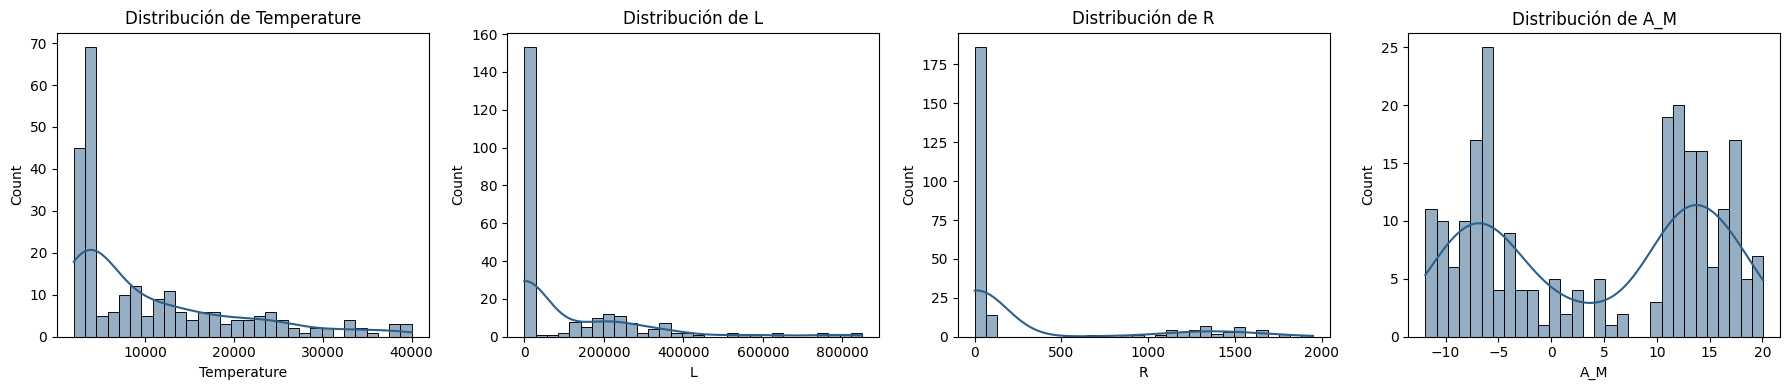

In [82]:
# ==========================================
# EDA 1: DISTRIBUCIONES UNIVARIANTES
# ==========================================
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
num_cols = ["Temperature", "L", "R", "A_M"]

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color="#2c5f8a")
    axes[i].set_title(f"Distribución de {col}")
    
plt.tight_layout()
plt.show()

**Conclusión de los Histogramas:**
El análisis univariante revela propiedades estructurales clave de nuestro conjunto estelar:
1.  **Distribuciones con Sesgo Extremo:** La Luminosidad (`L`) y el Radio (`R`) presentan un sesgo fuertemente asimétrico hacia la derecha, aplastando a la mayoría de las estrellas cerca del cero frente a unas pocas supergigantes masivas. La Temperatura (`Temperature`) también presenta un notable sesgo positivo.
2.  **Distribución Bimodal:** La Magnitud Absoluta (`A_M`) muestra dos picos distintos (distribución bimodal), sugiriendo la coexistencia de dos poblaciones estelares macroscópicas (ej. estrellas enanas vs. gigantes) separables por su brillo absoluto.

**Decisión técnica:** Para que el algoritmo PCA (que asume relaciones lineales) no colapse ante el sesgo de `L`, `R` y `Temperature`, y para linealizar la Ley de Stefan-Boltzmann ($L \propto R^2 T^4$), aplicaremos una **transformación logarítmica ($\log_{10}$)** a estas tres variables antes de estandarizar.

A continuación, construimos el **Diagrama de Hertzsprung-Russell (HR)**, la herramienta visual más importante en astrofísica, que relaciona la Temperatura Superficial (eje X, habitualmente invertido) con la Magnitud Absoluta (eje Y, invertido). Este diagrama nos permite ver la estructura intrínseca de los clústeres estelares *antes* de aplicar el modelo de Machine Learning.

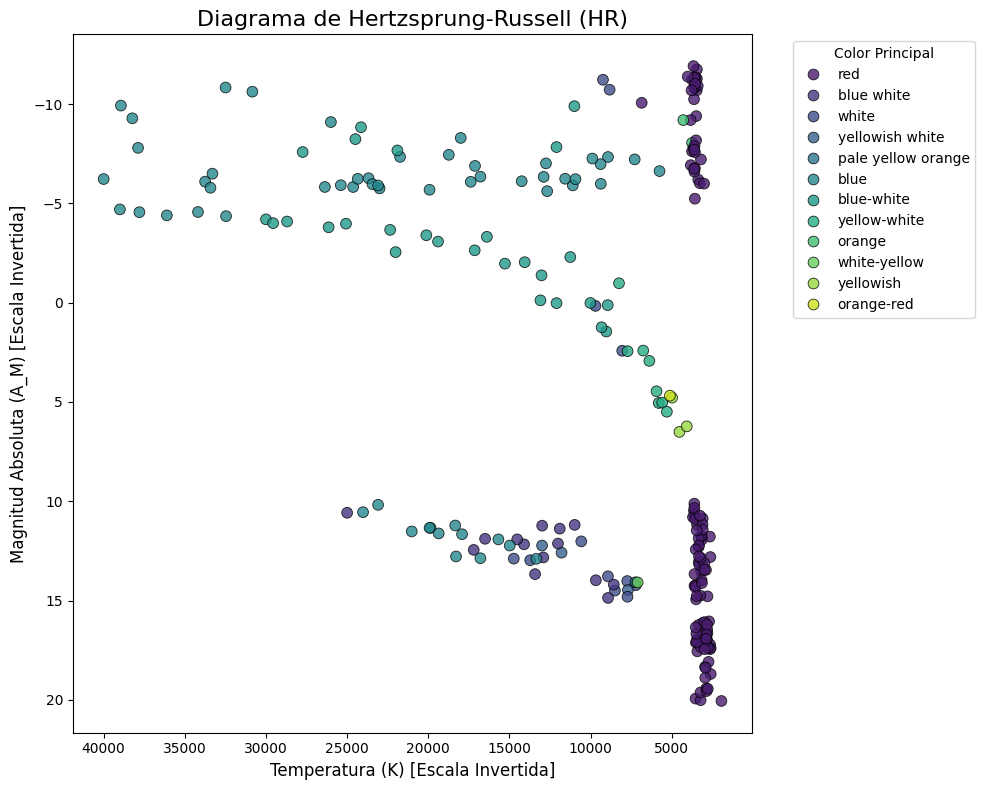

In [83]:
# ==========================================
# EDA 2: DIAGRAMA DE HERTZSPRUNG-RUSSELL
# ==========================================
plt.figure(figsize=(10, 8))

# Pintamos el scatter usando la codificación de color como hue para más detalle
scatter = sns.scatterplot(
    x="Temperature", 
    y="A_M", 
    hue="Color", 
    data=df, 
    palette="viridis",
    s=60, 
    alpha=0.8,
    edgecolor="black"
)

# En astronomía, el diagrama HR se pinta con la Temperatura decreciente hacia la derecha
# y la Magnitud Absoluta (que a menor valor, mayor brillo) invertida.
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.title("Diagrama de Hertzsprung-Russell (HR)", fontsize=16)
plt.xlabel("Temperatura (K) [Escala Invertida]", fontsize=12)
plt.ylabel("Magnitud Absoluta (A_M) [Escala Invertida]", fontsize=12)
plt.legend(title="Color Principal", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 1.4 Transformación Matemática y Estandarización

Es crucial distinguir entre transformación de varianza y escalado. Basándonos en nuestro EDA, aplicaremos una estrategia híbrida:

1.  **Transformación Logarítmica ($\log_{10}$):** Se aplica *exclusivamente* a `L`, `R` y `Temperature`. Esto domará su sesgo asimétrico y linealizará la relación física dictada por la Ley de Stefan-Boltzmann.
2.  **Exclusión de `A_M`:** La Magnitud Absoluta **no** recibe transformación logarítmica. Físicamente, `A_M` ya es una escala logarítmica invertida del brillo estelar. Matemáticamente, contiene valores negativos que generarían errores. Estadísticamente, debemos conservar su bimodalidad intacta (visible en el Diagrama HR).
3.  **Estandarización (`StandardScaler`):** Finalmente, pasamos TODAS las variables (transformadas y no transformadas) por un único escalador. Esto centra los datos ($\mu=0$) y unifica sus varianzas ($\sigma=1$), requisito fundamental para que el PCA funcione sin sesgos de escala.

In [84]:
# ========================================================
# TRANSFORMACIÓN LOGARÍTMICA Y ESTANDARIZACIÓN
# ========================================================

feature_cols = ["Temperature", "L", "R", "A_M", "Color_enc", "Spectral_Class_enc"]

# 1. Copia segura de las características para evitar sobreescrituras en df
X = df[feature_cols].copy()

# 2. Transformación logarítmica selectiva (base 10)
#    - Temperature, L, R: sesgo extremo hacia la derecha + relación física
#      no lineal (Stefan-Boltzmann: L ∝ R² · T⁴). El log linealiza esta relación.
#    - A_M: se excluye deliberadamente. Ya es una escala logarítmica del brillo
#      (magnitud), contiene valores negativos (gigantes brillantes) que harían
#      inválido el log, y su bimodalidad debe preservarse para el clustering.
#    - Color_enc, Spectral_Class_enc: son ordinales enteros [0, N], sin sesgo
#      de escala — no necesitan transformación logarítmica.
X["Temperature"] = np.log10(X["Temperature"])      # T > 0 siempre, sin offset
X["L"]           = np.log10(X["L"] + 1e-10)        # Offset de seguridad: L puede ser ~0
X["R"]           = np.log10(X["R"] + 1e-10)        # Ídem para R

# 3. Verificación: no deben existir NaN ni -inf tras el log
assert not np.any(np.isnan(X.values)),  "NaN detectado tras transformación logarítmica"
assert not np.any(np.isinf(X.values)), "-inf detectado tras transformación logarítmica"

# 4. Estandarización global (media=0, std=1)
#    Necesaria para que el PCA no esté dominado por las variables de mayor varianza.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. DataFrame con nombres descriptivos para trazabilidad
feature_cols_transformed = ["log10_Temp", "log10_L", "log10_R", "A_M", "Color_enc", "Spectral_Class_enc"]
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols_transformed)

# 6. Comprobación: medias ≈ 0, desviaciones ≈ 1
print("Verificación post-estandarización (deben ser ~0 y ~1 respectivamente):")
X_scaled_df.describe().loc[["mean", "std"]].round(4)

Verificación post-estandarización (deben ser ~0 y ~1 respectivamente):


,log10_Temp,log10_L,log10_R,A_M,Color_enc,Spectral_Class_enc
mean,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000
std,1.0021,1.0021,1.0021,1.0021,1.0021,1.0021


### 1.5 Reducción de dimensionalidad mediante PCA

Tal y como exige la práctica, reduciremos el espacio de características a **2 Componentes Principales**. Para garantizar la estricta reproducibilidad exigida en el enunciado, inyectaremos la semilla (NIA) en el algoritmo. Además, cuantificaremos cuánta información (varianza) logramos retener tras la compresión.

In [85]:
# ========================================================
# EJECUCIÓN DE PCA Y CÁLCULO DE VARIANZA
# ========================================================

# Utilizamos la semilla global para garantizar reproducibilidad
SEED = 100504112 

# 1. Instanciamos y entrenamos el PCA
pca = PCA(n_components=2, random_state=SEED)
X_pca_array = pca.fit_transform(X_scaled_df)

# 2. Creamos un DataFrame limpio y trazable para los algoritmos de clustering
df_pca = pd.DataFrame(data=X_pca_array, columns=['PC1', 'PC2'])

# 3. Análisis de la varianza explicada
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100
var_total = pca.explained_variance_ratio_.sum() * 100

print(f"--- Análisis de Varianza Retenida ---")
print(f"Varianza explicada por PC1: {var_pc1:.2f}%")
print(f"Varianza explicada por PC2: {var_pc2:.2f}%")
print(f"Varianza total capturada en 2D: {var_total:.2f}%")

# Mostramos las primeras filas del dataset que irá al clustering
display(df_pca.head())

--- Análisis de Varianza Retenida ---
Varianza explicada por PC1: 64.18%
Varianza explicada por PC2: 33.02%
Varianza total capturada en 2D: 97.20%


,PC1,PC2
0,2.303252,0.145558
1,2.409882,0.057129
2,2.632692,-0.022956
3,2.492931,0.059124
4,2.868641,0.026187


**Interpretación Física de las Componentes (Loadings):**
No podemos tratar las componentes `PC1` y `PC2` como "cajas negras". Para poder cruzar más adelante los resultados del clustering con las clases astronómicas reales, necesitamos extraer los "Loadings". Esto nos indicará qué peso (correlación) tiene cada variable física original en la construcción de los nuevos ejes.

In [86]:
# ========================================================
# EXTRACCIÓN DE LOADINGS (EXPLICABILIDAD)
# ========================================================

# Extraemos los pesos de las características originales en PC1 y PC2
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_cols
)

print("Cargas (Loadings) de las características originales en las Componentes Principales:")
# Usamos un mapa de calor integrado en pandas para ver rápidamente qué domina cada eje
display(loadings.style.background_gradient(cmap='coolwarm', axis=0).format(precision=3))

Cargas (Loadings) de las características originales en las Componentes Principales:


,PC1,PC2
Temperature,-0.419,-0.365
L,-0.432,0.364
R,-0.333,0.524
A_M,0.434,-0.358
Color_enc,-0.404,-0.419
Spectral_Class_enc,0.418,0.394


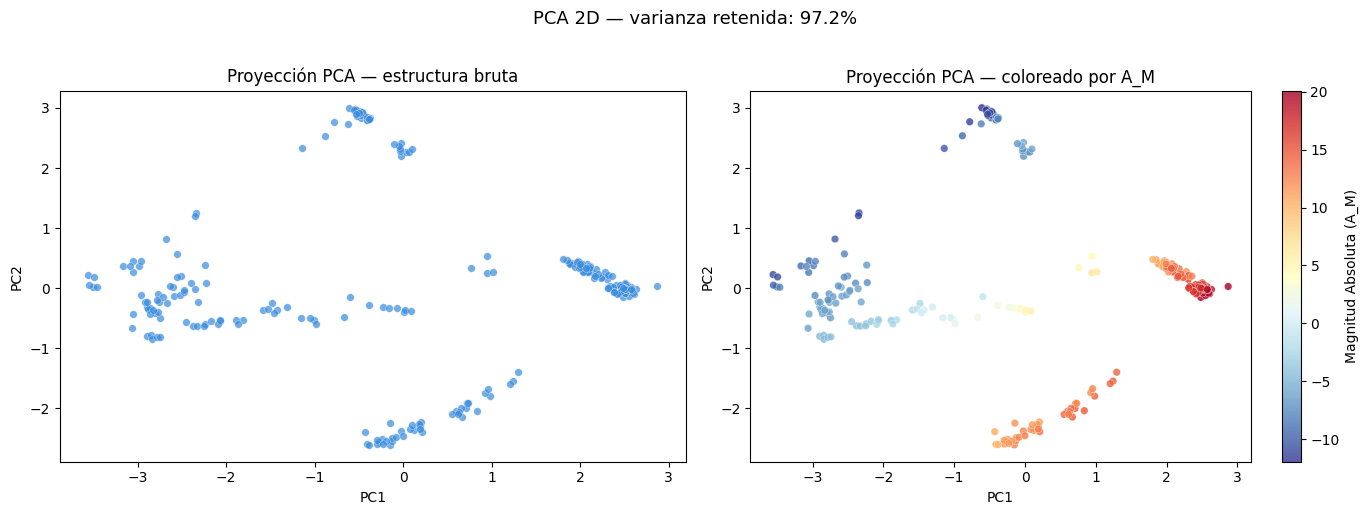

In [87]:
# ========================================================
# VISUALIZACIÓN DE LA PROYECCIÓN PCA
# ========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Panel izquierdo: puntos sin etiquetar (estructura bruta)
axes[0].scatter(
    X_pca_array[:, 0], X_pca_array[:, 1],
    s=30, alpha=0.7, color="#378ADD", edgecolors="white", linewidths=0.3
)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("Proyección PCA — estructura bruta")

# — Panel derecho: coloreado por Magnitud Absoluta (A_M)
# A_M es la variable más discriminante según el diagrama HR del EDA.
# Este coloreado nos permite anticipar visualmente la separación de clusters
# antes de aplicar ningún algoritmo.
sc = axes[1].scatter(
    X_pca_array[:, 0], X_pca_array[:, 1],
    c=df["A_M"], cmap="RdYlBu_r",
    s=30, alpha=0.8, edgecolors="white", linewidths=0.3
)
plt.colorbar(sc, ax=axes[1], label="Magnitud Absoluta (A_M)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("Proyección PCA — coloreado por A_M")

plt.suptitle(f"PCA 2D — varianza retenida: {var_total:.1f}%", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Conclusión del preprocesado

Las dos componentes principales retienen un **97.20% de la varianza total** del conjunto de datos transformado (ver salida de la celda anterior). Este porcentaje es el que el enunciado acepta como punto de partida para los algoritmos de clustering: todas las secciones siguientes operan exclusivamente sobre `df_pca` (PC1, PC2).

El panel derecho de la visualización muestra cómo la **Magnitud Absoluta** (`A_M`) ya estructura el espacio PCA en franjas bien diferenciadas, lo que anticipa que los algoritmos de clustering encontrarán grupos coherentes. PC1 concentra principalmente la información energética de la estrella (luminosidad, radio, temperatura), mientras que PC2 captura el componente espectral/cromático.

A continuación aplicamos los tres algoritmos exigidos por el enunciado: **K-Means**, **Hierarchical Clustering** y **DBSCAN**.